In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt

sys.path.append('../../datasets')
from load_data import get_datasets

2025-01-30 14:44:09.385027: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
ds_train, ds_val, ds_test, class_weights = get_datasets("cifar10")

labels = {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
            5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

2025-01-30 14:44:12.091404: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-01-30 14:44:12.113146: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-01-30 14:44:12.115074: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-01-30 14:44:12.117170: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the approp

In [3]:
from nutil.plot import paperStyle

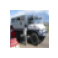

In [9]:
i = 0
for X, y in ds_train.take(20):
    if i == 11:
        with paperStyle():
            plt.figure(figsize=(0.5, 0.5))
            plt.imshow(X)
            plt.axis('off')
            
            plt.savefig('image.svg', bbox_inches='tight', dpi=300)
            plt.show()
        break
    i += 1

In [8]:
def get_class_distribution(ds):
    labels = [np.argmax(label) for _, label in ds]
    return np.bincount(labels, minlength=7)

In [9]:
train_distribution = get_class_distribution(ds_train)
val_distribution = get_class_distribution(ds_val)
test_distribution = get_class_distribution(ds_test)

In [10]:
def plot_distribution(distribution, title):
    fig, ax = plt.subplots()
    ax.pie(distribution, labels=labels, autopct='%1.1f%%')
    ax.axis('equal')
    plt.title(title)
    plt.show()

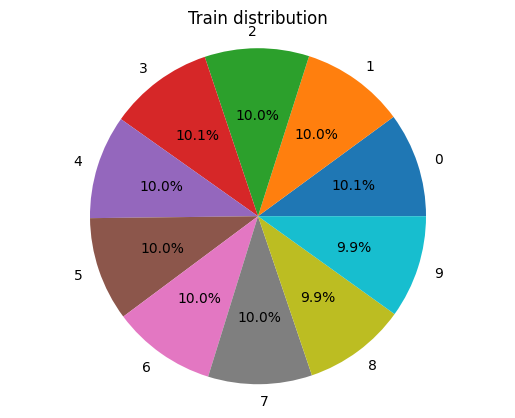

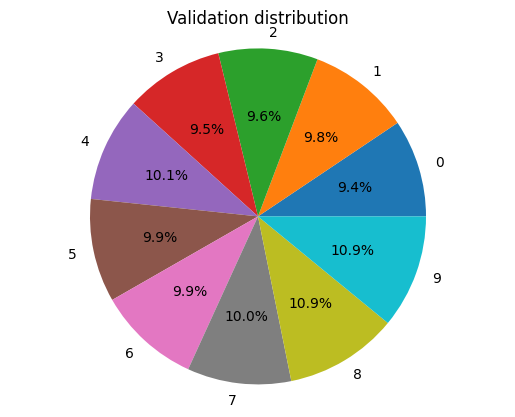

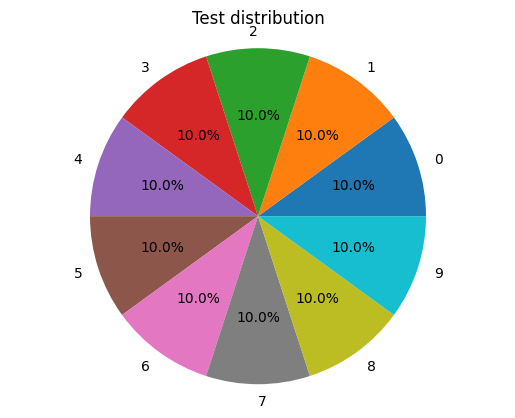

In [11]:
plot_distribution(train_distribution, 'Train distribution')
plot_distribution(val_distribution, 'Validation distribution')
plot_distribution(test_distribution, 'Test distribution')

In [13]:
# print raw numbers of samples presented nicely in a table in markdown
print('| Class | Train | Validation | Test |')
print('|-------|-------|------------|------|')
for i in range(10):
    print(f'| {labels[i]} | {train_distribution[i]} | {val_distribution[i]} | {test_distribution[i]} |')
    

| Class | Train | Validation | Test |
|-------|-------|------------|------|
| airplane | 4530 | 470 | 1000 |
| automobile | 4508 | 492 | 1000 |
| bird | 4522 | 478 | 1000 |
| cat | 4526 | 474 | 1000 |
| deer | 4497 | 503 | 1000 |
| dog | 4503 | 497 | 1000 |
| frog | 4505 | 495 | 1000 |
| horse | 4500 | 500 | 1000 |
| ship | 4456 | 544 | 1000 |
| truck | 4453 | 547 | 1000 |
